<a href="https://colab.research.google.com/github/RafaXzaviero/BENGKEL-KODING/blob/main/BENGKOD_PENUGASAN1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
census_income = fetch_ucirepo(id=20)

# data (as pandas dataframes)
X = census_income.data.features
y = census_income.data.targets

# metadata
print(census_income.metadata)

# variable information
print(census_income.variables)


{'uci_id': 20, 'name': 'Census Income', 'repository_url': 'https://archive.ics.uci.edu/dataset/20/census+income', 'data_url': 'https://archive.ics.uci.edu/static/public/20/data.csv', 'abstract': 'Predict whether income exceeds $50K/yr based on census data.  Also known as Adult dataset.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Mon Sep 09 2024', 'dataset_doi': '10.24432/C5GP7S', 'creators': ['Ron Kohavi'], 'intro_paper': None, 'additional_info': {'summary': 'Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && 

### 1. Menggabungkan Dataset Fitur dan Target

Dataset telah berhasil diunduh dan dipisahkan menjadi `X` (fitur) dan `y` (target). Menggabungkan keduanya menjadi satu DataFrame tunggal untuk memudahkan analisis.

In [3]:
# Menggabungkan X dan y menjadi satu DataFrame
df = X.copy()
df['income'] = y

print("DataFrame berhasil digabungkan.")
display(df.head())

DataFrame berhasil digabungkan.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2. Pemberian Nama Kolom

Kolom-kolom dalam DataFrame sudah memiliki nama. Dan kita akan memastikan nama kolom sesuai dan tidak ada spasi di awal/akhir nama kolom yang mungkin menyebabkan masalah.

In [4]:
# Menghilangkan spasi pada nama kolom
df.columns = df.columns.str.strip()

print("Nama kolom setelah dibersihkan:")
print(df.columns)

Nama kolom setelah dibersihkan:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


### 3. Menampilkan Informasi Kolom, 5 Record Pertama dan Terakhir Dataset, dan Ringkasan Statistik Dataset

Ini adalah langkah awal untuk memahami struktur, tipe data, dan distribusi statistik dari setiap kolom.

In [5]:
print("\n--- Informasi DataFrame ---")
df.info()

print("\n--- 5 Record Pertama ---")
display(df.head())

print("\n--- 5 Record Terakhir ---")
display(df.tail())

print("\n--- Ringkasan Statistik ---")
display(df.describe(include='all'))


--- Informasi DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- 5 Record Pertama ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



--- 5 Record Terakhir ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K.



--- Ringkasan Statistik ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### 4. Memeriksa Missing Value

Menganalisis keberadaan missing value adalah krusial karena dapat mempengaruhi kualitas dan performa model.

In [6]:
print("\n--- Jumlah Missing Value per Kolom ---")
display(df.isnull().sum())


--- Jumlah Missing Value per Kolom ---


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


### 5. Memeriksa Duplikasi Data

Duplikasi data dapat menyebabkan bias dalam analisis dan pelatihan model.

In [7]:
print("\n--- Jumlah Duplikasi Data ---")
duplicates_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates_count}")

if duplicates_count > 0:
    print("Menampilkan beberapa baris duplikat:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head())


--- Jumlah Duplikasi Data ---
Jumlah baris duplikat: 29
Menampilkan beberapa baris duplikat:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K.
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


### 6. Memeriksa Outlier

Outlier dapat dideteksi dengan visualisasi seperti box plot untuk kolom numerik.


--- Box Plot untuk Kolom Numerik (Deteksi Outlier) ---


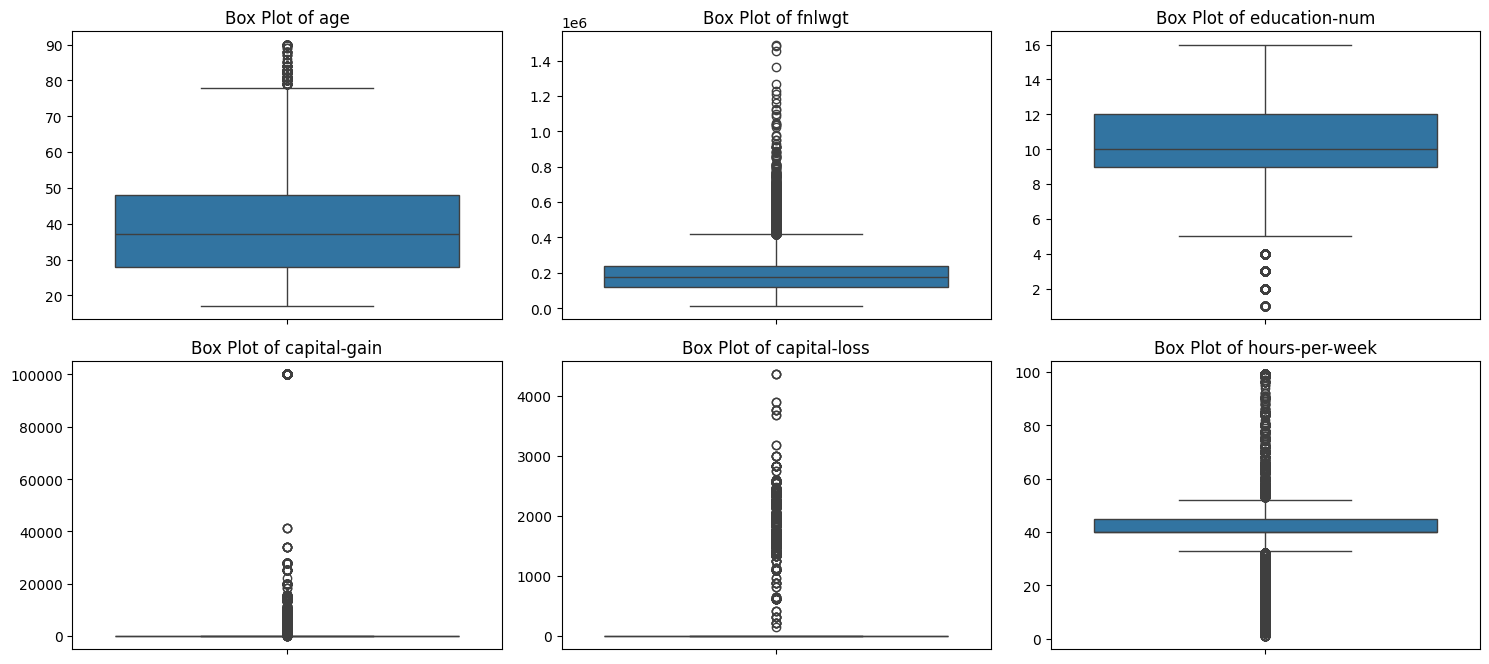

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\n--- Box Plot untuk Kolom Numerik (Deteksi Outlier) ---")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Menyesuaikan grid subplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 7. Memeriksa Ketidakseimbangan Data

Ini penting terutama untuk kolom target dalam masalah klasifikasi, seperti kolom `income`.

In [9]:
print("\n--- Distribusi Kolom Target 'income' ---")
display(df['income'].value_counts())
display(df['income'].value_counts(normalize=True) * 100)


--- Distribusi Kolom Target 'income' ---


,count
income,
<=50K,24720
<=50K.,12435
>50K,7841
>50K.,3846


,proportion
income,
<=50K,50.612178
<=50K.,25.459645
>50K,16.053806
>50K.,7.874370


### 8. Memisahkan Kolom Numerik dan Kategorik

Memisahkan kolom berdasarkan tipe datanya akan memudahkan langkah-langkah pemrosesan selanjutnya.

In [10]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\n--- Kolom Numerik ---")
print(numerical_features)

print("\n--- Kolom Kategorikal ---")
print(categorical_features)


--- Kolom Numerik ---
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

--- Kolom Kategorikal ---
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### 9. Melakukan Visualisasi Distribusi Kolom Numerik dan Kategorik

Visualisasi membantu kita memahami pola dan distribusi data dengan lebih baik.


--- Histograms untuk Kolom Numerik ---


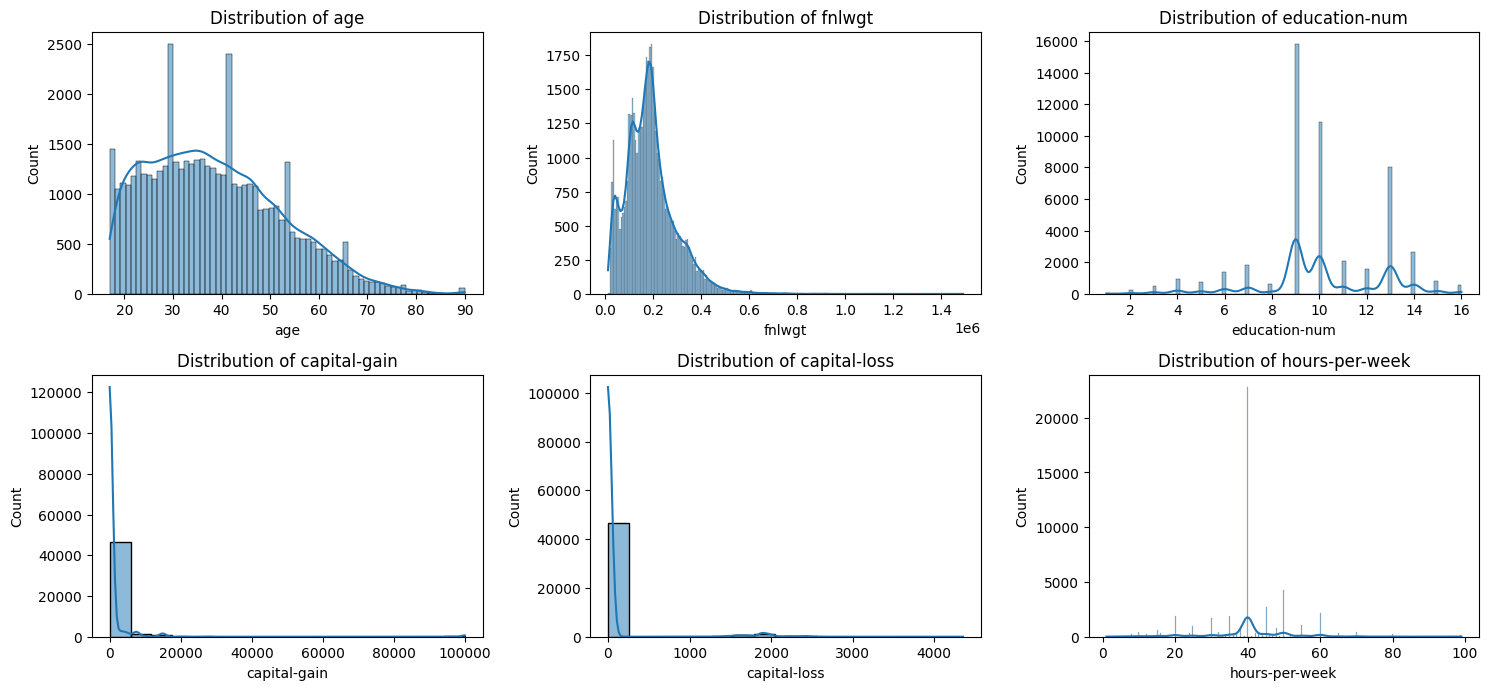


--- Bar Plots untuk Kolom Kategorikal ---


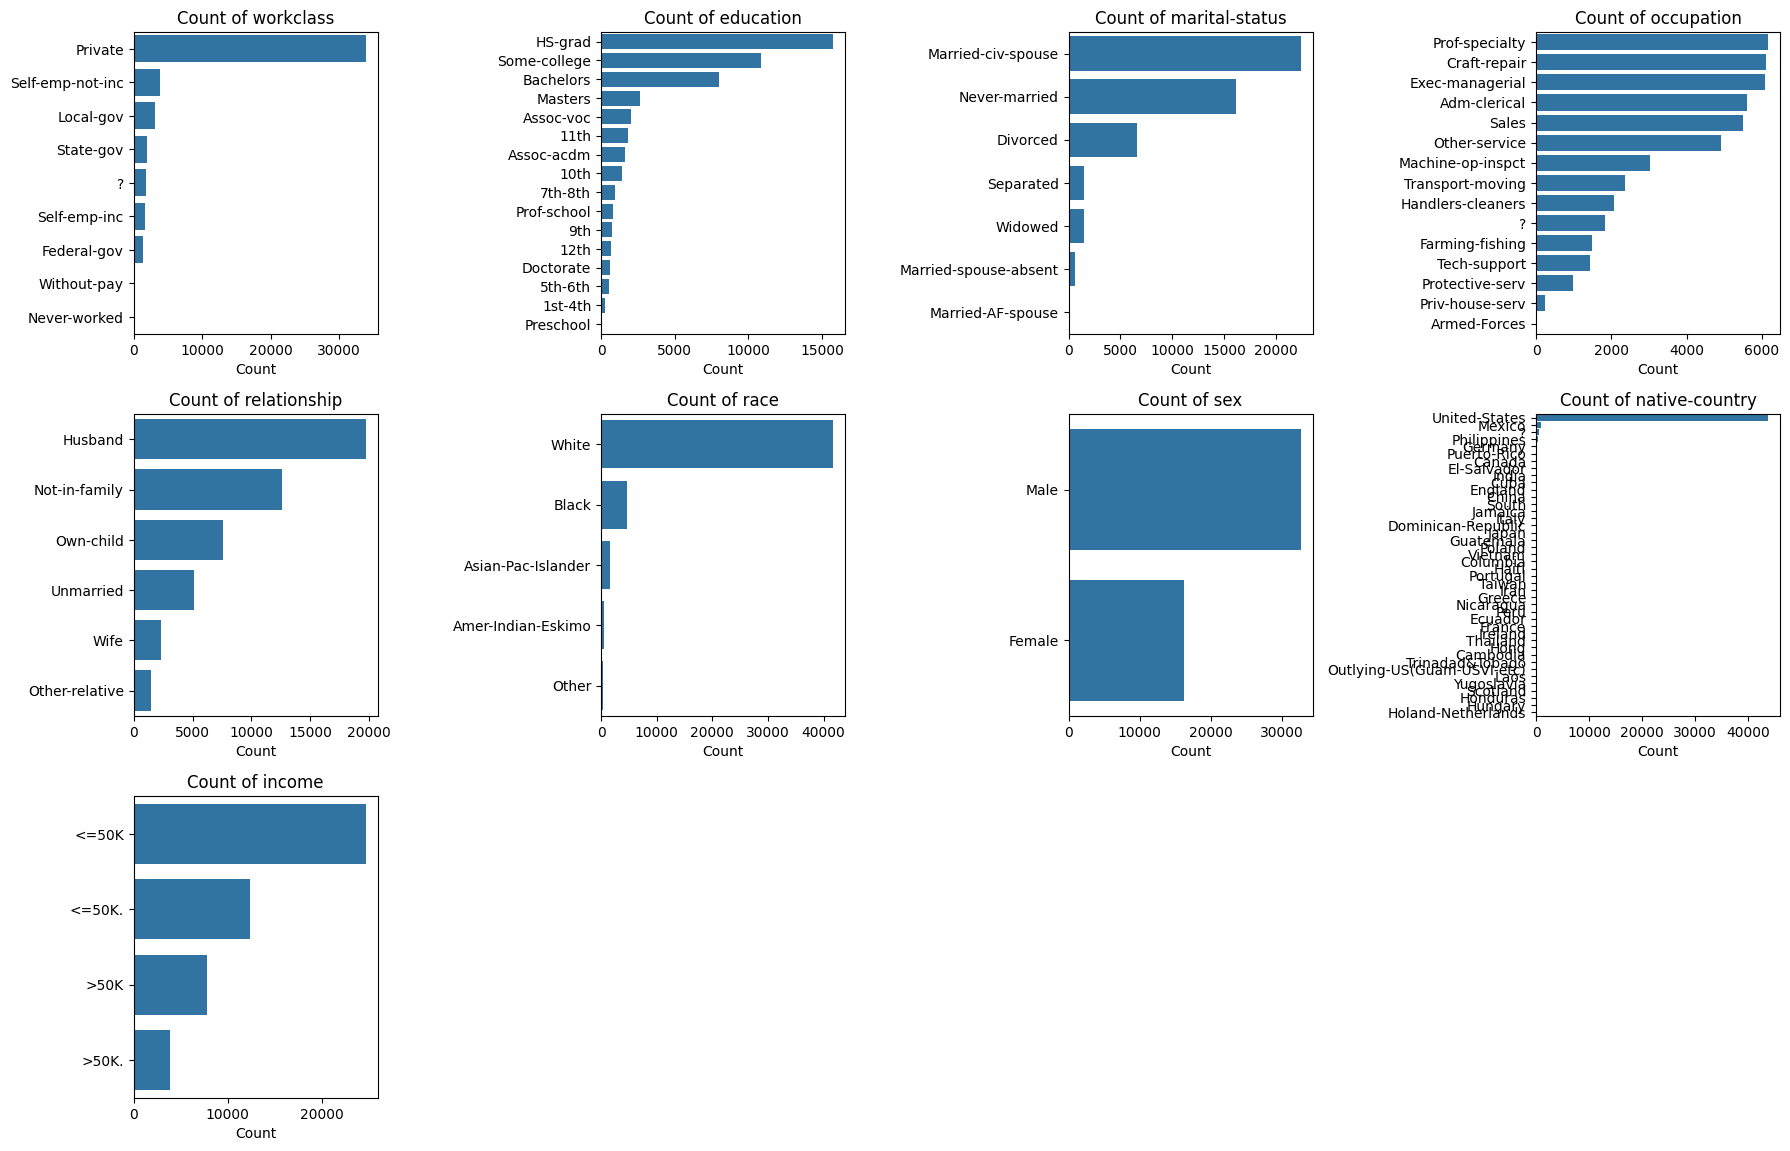

In [11]:
print("\n--- Histograms untuk Kolom Numerik ---")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("\n--- Bar Plots untuk Kolom Kategorikal ---")
plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_features):
    plt.subplot(4, 4, i + 1) # Menyesuaikan grid subplot
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 10. Deskripsi & Dokumentasi

Setiap langkah dalam notebook ini telah dilengkapi dengan penjelasan dan deskripsi singkat untuk memudahkan pemahaman. Insight baru yang diperoleh selama eksplorasi data meliputi:

- **Missing Values**: Ditemukan missing values pada kolom `workclass`, `occupation`, dan `native-country`.
- **Duplikasi Data**: Terdapat sejumlah baris duplikat yang perlu ditangani.
- **Outlier**: Beberapa kolom numerik seperti `fnlwgt`, `capital-gain`, dan `capital-loss` menunjukkan adanya outlier yang signifikan, yang mungkin memerlukan penanganan khusus.
- **Ketidakseimbangan Kelas**: Kolom target `income` menunjukkan ketidakseimbangan yang jelas, di mana mayoritas individu memiliki pendapatan `<=50K`.
- **Distribusi Data**: Distribusi kolom numerik dan kategorikal telah divisualisasikan untuk mendapatkan pemahaman awal tentang pola data.

In [12]:
print (df.isna().sum().sort_values(ascending=False))

occupation        966
workclass         963
native-country    274
fnlwgt              0
education           0
education-num       0
age                 0
marital-status      0
relationship        0
sex                 0
race                0
capital-gain        0
capital-loss        0
hours-per-week      0
income              0
dtype: int64


### 11. Kesimpulan

Eksplorasi data awal pada dataset Census Income ini telah memberikan pemahaman fundamental tentang struktur, kualitas, dan karakteristik data:

1.  **Kualitas Data**: Dataset relatif bersih namun memiliki beberapa missing values dan duplikasi yang perlu ditangani pada tahap pra-pemrosesan data selanjutnya.
2.  **Outlier**: Keberadaan outlier pada fitur numerik menunjukkan variasi yang ekstrem dan potensi dampak terhadap performa model jika tidak ditangani dengan baik.
3.  **Ketidakseimbangan Kelas**: Target `income` yang tidak seimbang mengindikasikan bahwa model klasifikasi mungkin perlu menggunakan teknik penanganan ketidakseimbangan (misalnya, *oversampling*, *undersampling*, atau penyesuaian bobot kelas) untuk mencegah bias pada kelas mayoritas.
4.  **Distribusi Fitur**: Visualisasi histogram dan bar plot membantu mengidentifikasi distribusi unik dari setiap fitur, yang akan memandu pemilihan strategi encoding untuk fitur kategorikal dan scaling untuk fitur numerik.